# Optimized Random Forest & XGBoost for CPI MoM Inflation

Clean notebook for optimized tree-based forecasting of `cpi_mom_inflation`.

Important note: the notebook is designed to improve model performance and avoid common leakage/alignment issues, but it does not force or guarantee `R² ≈ 0.5`. A target R² should be treated as an empirical outcome, not a parameter that can be guaranteed.

Main improvements over the earlier version:
- Consistent train/validation/test split.
- Correct feature alignment without resetting indices incorrectly.
- Stationarity-safe transformation for exogenous variables.
- Rich lag features: 1–24 months.
- Cyclical seasonality: `month_sin`, `month_cos`.
- Rolling statistics shifted by one period to avoid leakage.
- Interaction features for selected macro-financial variables.
- TimeSeriesSplit tuning.
- Optional SHAP-based feature selection if `shap` is installed.
- Random Forest, XGBoost, and weighted ensemble.
- Residual diagnostics and residual-bootstrap prediction intervals.
- Future forecast with recursive feature updates using persistence assumptions for future exogenous variables.

In [25]:
import os, warnings, random
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import jarque_bera
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, ParameterGrid
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except Exception:
    HAS_XGB = False
    print("xgboost is not installed. Please install xgboost for the main model.")

try:
    import shap
    HAS_SHAP = True
except Exception:
    HAS_SHAP = False
    print("shap is not installed. SHAP feature selection will be skipped.")

plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

DATA_DIR = os.path.join(os.getcwd(), "data", "processed")
OUTPUT_DIR = os.path.join(os.getcwd(), "outputs", "step5_rf_xgboost_optimized")
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Data:", DATA_DIR)
print("Output:", OUTPUT_DIR)

Data: d:\Nam4-HK1\KLTN\Vietnam_economic_lakehouse\model_test\data\processed
Output: d:\Nam4-HK1\KLTN\Vietnam_economic_lakehouse\model_test\outputs\step5_rf_xgboost_optimized


In [26]:
# Load data
DATA_FILE = os.path.join(DATA_DIR, "cpi_forecast_selected_variables.csv")
raw = pd.read_csv(DATA_FILE)

if "date" in raw.columns:
    raw["date"] = pd.to_datetime(raw["date"])
    df_raw = raw.sort_values("date").set_index("date")
else:
    df_raw = pd.read_csv(DATA_FILE, index_col=0, parse_dates=True).sort_index()

target_var = "cpi_mom_inflation"
exog_vars = [c for c in df_raw.columns if c != target_var]

df_raw = df_raw[[target_var] + exog_vars].copy().dropna()

print("Shape:", df_raw.shape)
print("Period:", df_raw.index.min().date(), "to", df_raw.index.max().date())
print("Missing:", df_raw.isnull().sum().sum())
print("Target:", target_var)
print("Exogenous variables:", exog_vars)

Shape: (360, 9)
Period: 1995-01-01 to 2024-12-01
Missing: 0
Target: cpi_mom_inflation
Exogenous variables: ['broad_money', 'ppi_qoq', 'wti', 'gold', 'policy_rate', 'VNINDEX', 'NIKKEI225', 'USDVND']


In [27]:
# Robust stationarity check and transformation for exogenous variables.
# Target is already CPI MoM inflation and is kept in level form.

def safe_stationarity_classification(series):
    s = pd.Series(series).dropna()
    s = pd.to_numeric(s, errors="coerce").dropna()

    if len(s) < 30 or s.nunique() <= 1:
        return "I(0)", np.nan, np.nan

    try:
        adf_p = adfuller(s, autolag="AIC", regression="c")[1]
    except Exception:
        adf_p = 1.0

    try:
        kpss_p = kpss(s, regression="c", nlags="auto")[1]
    except Exception:
        kpss_p = 0.01

    status = "I(0)" if (adf_p < 0.05 and kpss_p > 0.05) else "I(1)"
    return status, adf_p, kpss_p

transformed = {target_var: df_raw[target_var]}
transform_methods = {target_var: "level"}
stationarity_report = []

for col in exog_vars:
    status, adf_p, kpss_p = safe_stationarity_classification(df_raw[col])

    if status == "I(0)":
        new_col = col
        transformed[new_col] = df_raw[col]
        method = "level"
    else:
        if (df_raw[col] > 0).all():
            new_col = f"dlog_{col}"
            transformed[new_col] = np.log(df_raw[col]).diff()
            method = "log_diff"
        else:
            new_col = f"diff_{col}"
            transformed[new_col] = df_raw[col].diff()
            method = "diff"

    transform_methods[col] = method
    stationarity_report.append({"variable": col, "status": status, "adf_p": adf_p, "kpss_p": kpss_p, "method": method, "new_col": new_col})

df = pd.DataFrame(transformed, index=df_raw.index).dropna()
exog_transformed = [c for c in df.columns if c != target_var]
stationarity_df = pd.DataFrame(stationarity_report)

print("Transformed data shape:", df.shape)
print(stationarity_df)

Transformed data shape: (359, 9)
      variable status     adf_p  kpss_p    method           new_col
0  broad_money   I(1)  0.280602    0.01  log_diff  dlog_broad_money
1      ppi_qoq   I(1)  0.307828    0.01      diff      diff_ppi_qoq
2          wti   I(1)  0.121689    0.01  log_diff          dlog_wti
3         gold   I(1)  0.989363    0.01  log_diff         dlog_gold
4  policy_rate   I(1)  0.121117    0.01  log_diff  dlog_policy_rate
5      VNINDEX   I(1)  0.721155    0.01  log_diff      dlog_VNINDEX
6    NIKKEI225   I(1)  0.991552    0.01  log_diff    dlog_NIKKEI225
7       USDVND   I(1)  0.786262    0.01  log_diff       dlog_USDVND


In [28]:
# Feature engineering: all lag/rolling features use past information only.

def create_tree_features(data, target_col, exog_cols, max_target_lag=24):
    X = pd.DataFrame(index=data.index)
    y = data[target_col].copy()

    # Current transformed exogenous variables are assumed known at forecast origin only for historical testing.
    # For strict one-month-ahead production forecasting, lagged exog features are safer and are included below.
    for col in exog_cols:
        X[col] = data[col]

    # Target lags
    for lag in range(1, max_target_lag + 1):
        X[f"{target_col}_lag{lag}"] = y.shift(lag)

    # Exogenous lags and rolling statistics
    for col in exog_cols:
        for lag in [1, 2, 3, 6, 12]:
            X[f"{col}_lag{lag}"] = data[col].shift(lag)
        for window in [3, 6, 12]:
            X[f"{col}_roll_mean_{window}"] = data[col].rolling(window).mean().shift(1)
            X[f"{col}_roll_std_{window}"] = data[col].rolling(window).std().shift(1)

    # Target rolling statistics
    for window in [3, 6, 12]:
        X[f"{target_col}_roll_mean_{window}"] = y.rolling(window).mean().shift(1)
        X[f"{target_col}_roll_std_{window}"] = y.rolling(window).std().shift(1)
        X[f"{target_col}_roll_min_{window}"] = y.rolling(window).min().shift(1)
        X[f"{target_col}_roll_max_{window}"] = y.rolling(window).max().shift(1)

    # Seasonality: cyclical month encoding is better than raw integer month.
    month = data.index.month
    X["month_sin"] = np.sin(2 * np.pi * month / 12)
    X["month_cos"] = np.cos(2 * np.pi * month / 12)
    X["quarter_sin"] = np.sin(2 * np.pi * data.index.quarter / 4)
    X["quarter_cos"] = np.cos(2 * np.pi * data.index.quarter / 4)

    # Regime indicators based on past inflation volatility
    X["inflation_volatility_12m"] = y.rolling(12).std().shift(1)
    high_vol_threshold = X["inflation_volatility_12m"].quantile(0.75)
    X["high_vol_regime"] = (X["inflation_volatility_12m"] > high_vol_threshold).astype(float)

    # Interaction features: keep limited set to avoid too many noisy variables.
    key_exog = [c for c in exog_cols if any(k in c.lower() for k in ["wti", "gold", "usdvnd", "money", "policy"])]
    for col in key_exog[:5]:
        X[f"lag1_x_{col}_lag1"] = X[f"{target_col}_lag1"] * X[f"{col}_lag1"]
        X[f"vol_x_{col}_lag1"] = X["inflation_volatility_12m"] * X[f"{col}_lag1"]

    feature_df = pd.concat([X, y.rename(target_col)], axis=1).dropna()
    X = feature_df.drop(columns=[target_col])
    y = feature_df[target_col]

    return X, y, high_vol_threshold

X, y, high_vol_threshold = create_tree_features(df, target_var, exog_transformed, max_target_lag=24)

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("Feature period:", X.index.min().date(), "to", X.index.max().date())
print("High-vol threshold:", round(high_vol_threshold, 6))
print("First 10 features:", X.columns[:10].tolist())

Feature matrix shape: (335, 148)
Target shape: (335,)
Feature period: 1997-02-01 to 2024-12-01
High-vol threshold: 0.955502
First 10 features: ['dlog_broad_money', 'diff_ppi_qoq', 'dlog_wti', 'dlog_gold', 'dlog_policy_rate', 'dlog_VNINDEX', 'dlog_NIKKEI225', 'dlog_USDVND', 'cpi_mom_inflation_lag1', 'cpi_mom_inflation_lag2']


In [29]:
# Consistent chronological split: 80% train, 10% validation, 10% test.
n_total = len(X)
train_end = int(0.80 * n_total)
val_end = int(0.90 * n_total)

X_train, y_train = X.iloc[:train_end], y.iloc[:train_end]
X_val, y_val = X.iloc[train_end:val_end], y.iloc[train_end:val_end]
X_test, y_test = X.iloc[val_end:], y.iloc[val_end:]

print("Chronological split")
print(f"Train: {X_train.shape}, {X_train.index.min().date()} to {X_train.index.max().date()}")
print(f"Val:   {X_val.shape}, {X_val.index.min().date()} to {X_val.index.max().date()}")
print(f"Test:  {X_test.shape}, {X_test.index.min().date()} to {X_test.index.max().date()}")

assert X_train.index.equals(y_train.index)
assert X_val.index.equals(y_val.index)
assert X_test.index.equals(y_test.index)

Chronological split
Train: (268, 148), 1997-02-01 to 2019-05-01
Val:   (33, 148), 2019-06-01 to 2022-02-01
Test:  (34, 148), 2022-03-01 to 2024-12-01


Running SHAP-based feature selection...
Selected top 35 SHAP features
                       feature  importance
                     month_sin    0.164993
                      dlog_wti    0.055435
 cpi_mom_inflation_roll_mean_6    0.038746
                   quarter_sin    0.033377
       cpi_mom_inflation_lag24    0.030983
       cpi_mom_inflation_lag12    0.030916
         dlog_broad_money_lag3    0.025403
        cpi_mom_inflation_lag2    0.021317
                     dlog_gold    0.019705
          dlog_gold_roll_std_6    0.019034
 cpi_mom_inflation_roll_mean_3    0.018676
 cpi_mom_inflation_roll_std_12    0.015377
    dlog_NIKKEI225_roll_mean_6    0.015296
       cpi_mom_inflation_lag22    0.014868
              dlog_USDVND_lag6    0.014849
       cpi_mom_inflation_lag23    0.014601
      dlog_USDVND_roll_mean_12    0.012547
                dlog_gold_lag6    0.012292
         dlog_policy_rate_lag2    0.012064
        dlog_broad_money_lag12    0.011340
       dlog_USDVND_roll_std

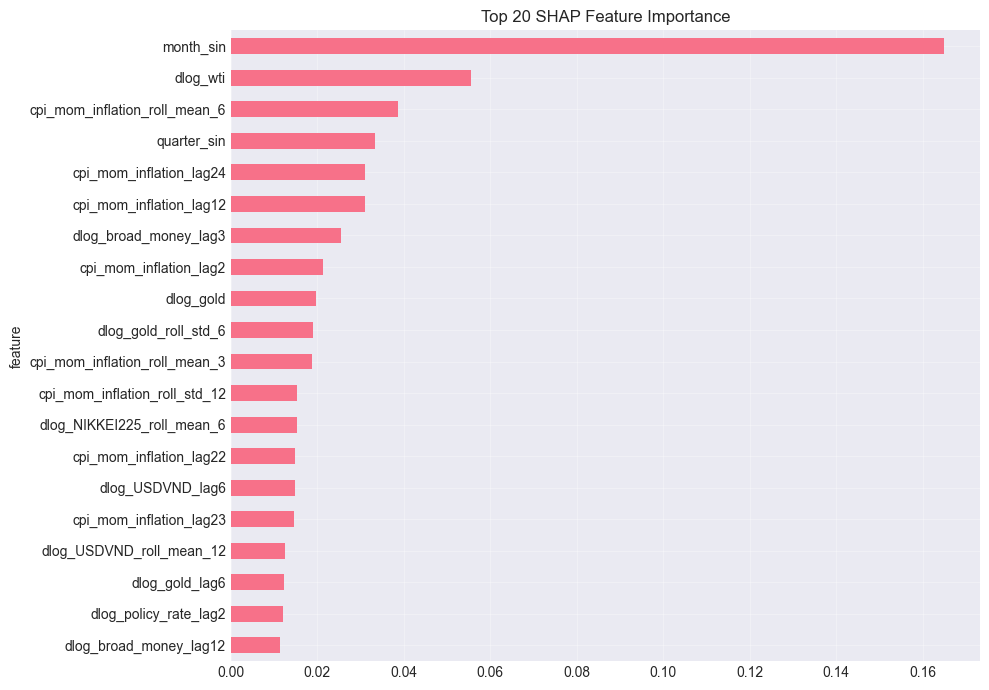

Selected feature count: 35


In [30]:
# Optional SHAP feature selection. If shap is not available, use all features.
USE_SHAP_SELECTION = HAS_SHAP
TOP_N = 35

if USE_SHAP_SELECTION and HAS_XGB:
    print("Running SHAP-based feature selection...")
    xgb_for_shap = XGBRegressor(
        n_estimators=150,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="reg:squarederror",
        random_state=SEED,
        n_jobs=-1,
        verbosity=0
    )
    xgb_for_shap.fit(X_train, y_train, verbose=False)
    explainer = shap.TreeExplainer(xgb_for_shap)
    shap_values = explainer.shap_values(X_val)
    shap_importance = np.abs(shap_values).mean(axis=0)

    shap_df = pd.DataFrame({"feature": X_train.columns, "importance": shap_importance}).sort_values("importance", ascending=False)
    selected_features = shap_df.head(TOP_N)["feature"].tolist()

    print(f"Selected top {TOP_N} SHAP features")
    print(shap_df.head(TOP_N).to_string(index=False))

    fig, ax = plt.subplots(figsize=(10, 7))
    shap_df.head(20).iloc[::-1].plot(x="feature", y="importance", kind="barh", ax=ax, legend=False)
    ax.set_title("Top 20 SHAP Feature Importance")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "shap_feature_importance.png"), dpi=150)
    plt.show()
else:
    selected_features = X_train.columns.tolist()
    print("SHAP selection skipped. Using all features:", len(selected_features))

X_train_sel = X_train[selected_features]
X_val_sel = X_val[selected_features]
X_test_sel = X_test[selected_features]

print("Selected feature count:", len(selected_features))

In [31]:
# TimeSeriesSplit tuning for Random Forest and XGBoost.

def tune_random_forest(X_train, y_train):
    param_grid = list(ParameterGrid({
        "n_estimators": [200, 400],
        "max_depth": [4, 6, 8, 10, None],
        "min_samples_leaf": [2, 4, 8],
        "max_features": ["sqrt", 0.5, 0.8]
    }))

    tss = TimeSeriesSplit(n_splits=4)
    best_score = np.inf
    best_params = None

    for params in param_grid:
        fold_scores = []
        for tr_idx, va_idx in tss.split(X_train):
            X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
            y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]

            model = RandomForestRegressor(**params, random_state=SEED, n_jobs=-1)
            model.fit(X_tr, y_tr)
            pred = model.predict(X_va)
            fold_scores.append(np.sqrt(mean_squared_error(y_va, pred)))

        score = np.mean(fold_scores)
        if score < best_score:
            best_score = score
            best_params = params

    return best_params, best_score


def tune_xgboost(X_train, y_train):
    if not HAS_XGB:
        return None, np.nan

    param_grid = list(ParameterGrid({
        "n_estimators": [100, 200, 400],
        "max_depth": [2, 3, 4, 5],
        "learning_rate": [0.01, 0.03, 0.05, 0.08],
        "subsample": [0.75, 0.9, 1.0],
        "colsample_bytree": [0.75, 0.9, 1.0],
        "reg_alpha": [0.0, 0.1, 0.5],
        "reg_lambda": [0.5, 1.0, 2.0]
    }))

    # Limit grid size for runtime while keeping deterministic sampling.
    rng = np.random.default_rng(SEED)
    if len(param_grid) > 120:
        param_grid = list(rng.choice(param_grid, size=120, replace=False))

    tss = TimeSeriesSplit(n_splits=4)
    best_score = np.inf
    best_params = None

    for params in param_grid:
        fold_scores = []
        for tr_idx, va_idx in tss.split(X_train):
            X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
            y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]

            model = XGBRegressor(
                **params,
                objective="reg:squarederror",
                random_state=SEED,
                n_jobs=-1,
                verbosity=0
            )
            model.fit(X_tr, y_tr, verbose=False)
            pred = model.predict(X_va)
            fold_scores.append(np.sqrt(mean_squared_error(y_va, pred)))

        score = np.mean(fold_scores)
        if score < best_score:
            best_score = score
            best_params = params

    return best_params, best_score

print("Tuning Random Forest...")
best_rf_params, best_rf_cv = tune_random_forest(X_train_sel, y_train)
print("Best RF params:", best_rf_params)
print("Best RF CV RMSE:", round(best_rf_cv, 6))

print("\nTuning XGBoost...")
best_xgb_params, best_xgb_cv = tune_xgboost(X_train_sel, y_train)
print("Best XGB params:", best_xgb_params)
print("Best XGB CV RMSE:", round(best_xgb_cv, 6))

Tuning Random Forest...
Best RF params: {'max_depth': None, 'max_features': 0.5, 'min_samples_leaf': 2, 'n_estimators': 400}
Best RF CV RMSE: 0.539914

Tuning XGBoost...
Best XGB params: {'colsample_bytree': 0.75, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 400, 'reg_alpha': 0.1, 'reg_lambda': 0.5, 'subsample': 0.75}
Best XGB CV RMSE: 0.531401


In [32]:
# Train final models on train + validation, evaluate on untouched test.
X_train_full = pd.concat([X_train_sel, X_val_sel])
y_train_full = pd.concat([y_train, y_val])

rf_best = RandomForestRegressor(**best_rf_params, random_state=SEED, n_jobs=-1)
rf_best.fit(X_train_full, y_train_full)
rf_test_pred = rf_best.predict(X_test_sel)

if HAS_XGB:
    xgb_best = XGBRegressor(
        **best_xgb_params,
        objective="reg:squarederror",
        random_state=SEED,
        n_jobs=-1,
        verbosity=0
    )
    xgb_best.fit(X_train_full, y_train_full, verbose=False)
    xgb_test_pred = xgb_best.predict(X_test_sel)
else:
    xgb_best = None
    xgb_test_pred = np.repeat(np.nan, len(y_test))

# Weighted ensemble using validation RMSE-based weights.
rf_val_model = RandomForestRegressor(**best_rf_params, random_state=SEED, n_jobs=-1)
rf_val_model.fit(X_train_sel, y_train)
rf_val_pred = rf_val_model.predict(X_val_sel)
rf_val_rmse = np.sqrt(mean_squared_error(y_val, rf_val_pred))

if HAS_XGB:
    xgb_val_model = XGBRegressor(**best_xgb_params, objective="reg:squarederror", random_state=SEED, n_jobs=-1, verbosity=0)
    xgb_val_model.fit(X_train_sel, y_train, verbose=False)
    xgb_val_pred = xgb_val_model.predict(X_val_sel)
    xgb_val_rmse = np.sqrt(mean_squared_error(y_val, xgb_val_pred))
else:
    xgb_val_rmse = np.inf

w_rf = 1 / (rf_val_rmse + 1e-8)
w_xgb = 1 / (xgb_val_rmse + 1e-8)
w_sum = w_rf + w_xgb
w_rf, w_xgb = w_rf / w_sum, w_xgb / w_sum

ensemble_test_pred = w_rf * rf_test_pred + w_xgb * xgb_test_pred if HAS_XGB else rf_test_pred

print("Validation RMSE for ensemble weighting")
print(f"RF val RMSE:  {rf_val_rmse:.6f}")
print(f"XGB val RMSE: {xgb_val_rmse:.6f}")
print(f"Weights -> RF: {w_rf:.3f}, XGB: {w_xgb:.3f}")

Validation RMSE for ensemble weighting
RF val RMSE:  0.677560
XGB val RMSE: 0.696383
Weights -> RF: 0.507, XGB: 0.493


In [33]:
def evaluate(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {"Model": name, "RMSE": rmse, "MAE": mae, "R2": r2}

# Proper Random Walk: y_t forecasted by y_{t-1}
rw_pred = df[target_var].shift(1).reindex(y_test.index).values
rw_mask = ~np.isnan(rw_pred)
rw_rmse = np.sqrt(mean_squared_error(y_test.values[rw_mask], rw_pred[rw_mask]))
rw_mae = mean_absolute_error(y_test.values[rw_mask], rw_pred[rw_mask])

mean_pred = np.repeat(np.mean(y_test), len(y_test))
mean_rmse = np.sqrt(mean_squared_error(y_test, mean_pred))
mean_mae = mean_absolute_error(y_test, mean_pred)

results = [
    {"Model": "Random Walk", "RMSE": rw_rmse, "MAE": rw_mae, "R2": np.nan},
    {"Model": "Mean Baseline", "RMSE": mean_rmse, "MAE": mean_mae, "R2": 0.0},
    evaluate(y_test, rf_test_pred, "Random Forest Optimized"),
]

if HAS_XGB:
    results.append(evaluate(y_test, xgb_test_pred, "XGBoost Optimized"))
    results.append(evaluate(y_test, ensemble_test_pred, "RF-XGB Weighted Ensemble"))

results_df = pd.DataFrame(results)
results_df["Model_vs_RW"] = results_df["RMSE"] / rw_rmse
results_df["Model_vs_Mean"] = results_df["RMSE"] / mean_rmse
results_df = results_df.sort_values("RMSE")

print("\n" + "="*80)
print("OPTIMIZED MODEL COMPARISON")
print("="*80)
print(results_df.to_string(index=False))
print("="*80)

best_model_name = results_df.iloc[0]["Model"]
print(f"Best model by RMSE: {best_model_name}")

results_df.to_csv(os.path.join(OUTPUT_DIR, "optimized_model_comparison.csv"), index=False)


OPTIMIZED MODEL COMPARISON
                   Model     RMSE      MAE       R2  Model_vs_RW  Model_vs_Mean
 Random Forest Optimized 0.394421 0.331945 0.163547     0.565014       0.914578
RF-XGB Weighted Ensemble 0.396678 0.326271 0.153948     0.568246       0.919811
       XGBoost Optimized 0.408808 0.326372 0.101410     0.585624       0.947940
           Mean Baseline 0.431260 0.341284 0.000000     0.617786       1.000000
             Random Walk 0.698073 0.533684      NaN     1.000000       1.618683
Best model by RMSE: Random Forest Optimized


## Residual Shock Correction with Gasoline Price (2018+)

In [45]:
# Load Vietnam gasoline prices from raw data
RAW_DIR = os.path.join(os.getcwd(), "data", "raw")

def load_gasoline_data(path):
    df = pd.read_csv(path)
    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"], format="mixed", dayfirst=True, errors="coerce")
        df = df.set_index("date").sort_index()
    return df

gasoline_vn = load_gasoline_data(os.path.join(RAW_DIR, "gasoline.csv"))


print("✓ Vietnam gasoline:", gasoline_vn.shape)

if len(gasoline_vn) > 0:
    print(f"  Vietnam: {gasoline_vn.index.min().date()} → {gasoline_vn.index.max().date()}")


✓ Vietnam gasoline: (1107, 7)
  Vietnam: 2018-08-22 → 2026-04-09


In [48]:
# Train residual correction model with Vietnam gasoline RON 95 price
# Step 1: Extract RON 95 gasoline prices and convert to monthly
ron95_data = gasoline_vn[gasoline_vn['product'] == 'RON 95'].copy()
ron95_monthly = ron95_data.groupby(ron95_data.index.to_period('M'))['price'].mean()
ron95_monthly.index = ron95_monthly.index.to_timestamp()

# Step 2: Calculate residuals on full period using best model
full_X = X[selected_features]
best_model = rf_best if best_model_name == "Random Forest Optimized" else xgb_best
full_pred = best_model.predict(full_X)
residuals_full = y.values - full_pred
residuals_ts = pd.Series(residuals_full, index=y.index)

# Step 3: Align gasoline data with CPI index
gas_aligned = ron95_monthly.reindex(y.index, method='ffill')
print(f"✓ RON 95 prices: {ron95_monthly.shape[0]} monthly observations ({ron95_monthly.index.min().date()} → {ron95_monthly.index.max().date()})")
print(f"✓ Aligned to CPI: {gas_aligned.notna().sum()} valid matches")

# Step 4: Filter 2018+ and create residual features
cutoff = pd.Timestamp('2018-01-01')
mask_2018 = y.index >= cutoff
resid_2018 = residuals_ts[mask_2018]
gas_2018 = gas_aligned[mask_2018]

# Simple 6-feature model: target_lag(1,2,3) + gas_lag(1,2,3)
X_resid_simple = pd.DataFrame(index=resid_2018.index)
for lag in [1, 2, 3]:
    X_resid_simple[f"resid_lag{lag}"] = resid_2018.shift(lag)
    X_resid_simple[f"ron95_lag{lag}"] = gas_2018.shift(lag)

X_resid_simple = X_resid_simple.dropna()
y_resid_train = resid_2018.loc[X_resid_simple.index]

print(f"✓ Training data: {X_resid_simple.shape[0]} samples from {X_resid_simple.index.min().date()}")

# Step 5: Train residual model
if len(X_resid_simple) > 10:
    resid_model = XGBRegressor(
        n_estimators=100, max_depth=3, learning_rate=0.05,
        subsample=0.9, colsample_bytree=0.9,
        objective="reg:squarederror", random_state=SEED, verbosity=0
    ) if HAS_XGB else None
    
    if resid_model:
        resid_model.fit(X_resid_simple, y_resid_train, verbose=False)
        print(f"✓ Residual model trained: MAE = {mean_absolute_error(y_resid_train, resid_model.predict(X_resid_simple)):.6f}")
    else:
        resid_model = None
else:
    print(f"⚠ Insufficient data ({len(X_resid_simple)} < 10)")
    resid_model = None

✓ RON 95 prices: 93 monthly observations (2018-08-01 → 2026-04-01)
✓ Aligned to CPI: 77 valid matches
✓ Training data: 74 samples from 2018-11-01
✓ Residual model trained: MAE = 0.095969


In [52]:
# Apply residual correction to test set
if resid_model is not None:
    # Create test residual features
    X_test_resid = pd.DataFrame(index=X_test.index)
    
    for lag in [1, 2, 3]:
        X_test_resid[f"resid_lag{lag}"] = residuals_ts.shift(lag).reindex(X_test.index)
        X_test_resid[f"ron95_lag{lag}"] = gas_aligned.shift(lag).reindex(X_test.index)
    
    # Get valid indices (all lags available)
    valid_idx = X_test_resid.dropna().index
    X_test_resid_clean = X_test_resid.loc[valid_idx]
    
    # Predict corrections
    resid_correction = np.zeros(len(X_test))
    valid_mask = X_test.index.isin(valid_idx)
    if len(X_test_resid_clean) > 0:
        resid_correction[valid_mask] = resid_model.predict(X_test_resid_clean)
    
    # Corrected forecast
    best_pred_corrected = best_pred + resid_correction
    
    # Performance comparison
    results_corrected = [
        evaluate(y_test, best_pred_corrected, f"{best_model_name} + RON95 Shock Correction"),
        results_df.iloc[0].to_dict()
    ]
    results_corrected_df = pd.DataFrame(results_corrected).sort_values("RMSE")
    
    print(f"\n{'='*80}")
    print("RESIDUAL CORRECTION WITH VIETNAM RON95 GASOLINE")
    print(f"{'='*80}")
    print(results_corrected_df[["Model", "RMSE", "MAE", "R2"]].to_string(index=False))
    
    print(f"\nSample corrections (first 10 test samples):")
    sample_df = pd.DataFrame({
        "Date": y_test.index[:10],
        "Actual": y_test.values[:10],
        "Base": best_pred[:10],
        "Correction": resid_correction[:10],
        "Corrected": best_pred_corrected[:10],
        "RON95_Price": gas_aligned.reindex(y_test.index).values[:10]
    })
    print(sample_df.round(4).to_string(index=False))
else:
    best_pred_corrected = best_pred
    print("⚠ Residual model not available")


RESIDUAL CORRECTION WITH VIETNAM RON95 GASOLINE
                                           Model     RMSE      MAE       R2
Random Forest Optimized + RON95 Shock Correction 0.147288 0.111347 0.883358
                         Random Forest Optimized 0.394421 0.331945 0.163547

Sample corrections (first 10 test samples):
      Date  Actual    Base  Correction  Corrected  RON95_Price
2022-03-01 -0.2970 -1.0693      0.3687    -0.7006   28613.3333
2022-04-01 -0.5164 -0.0630     -0.3411    -0.4041   27816.6667
2022-05-01  0.1996  0.4934     -0.1965     0.2969   29686.6667
2022-06-01  0.3088  0.1936      0.0728     0.2663   32270.0000
2022-07-01 -0.2880 -0.0693     -0.1663    -0.2357   29500.0000
2022-08-01 -0.3984 -0.1450     -0.1804    -0.3254   24973.3333
2022-09-01  0.4000  0.0742      0.2229     0.2971   23340.0000
2022-10-01 -0.2490  0.1077     -0.3033    -0.1956   21926.6667
2022-11-01  0.2396  0.1237      0.1303     0.2540   23463.3333
2022-12-01 -0.3984  0.3246     -0.3358    -0.011

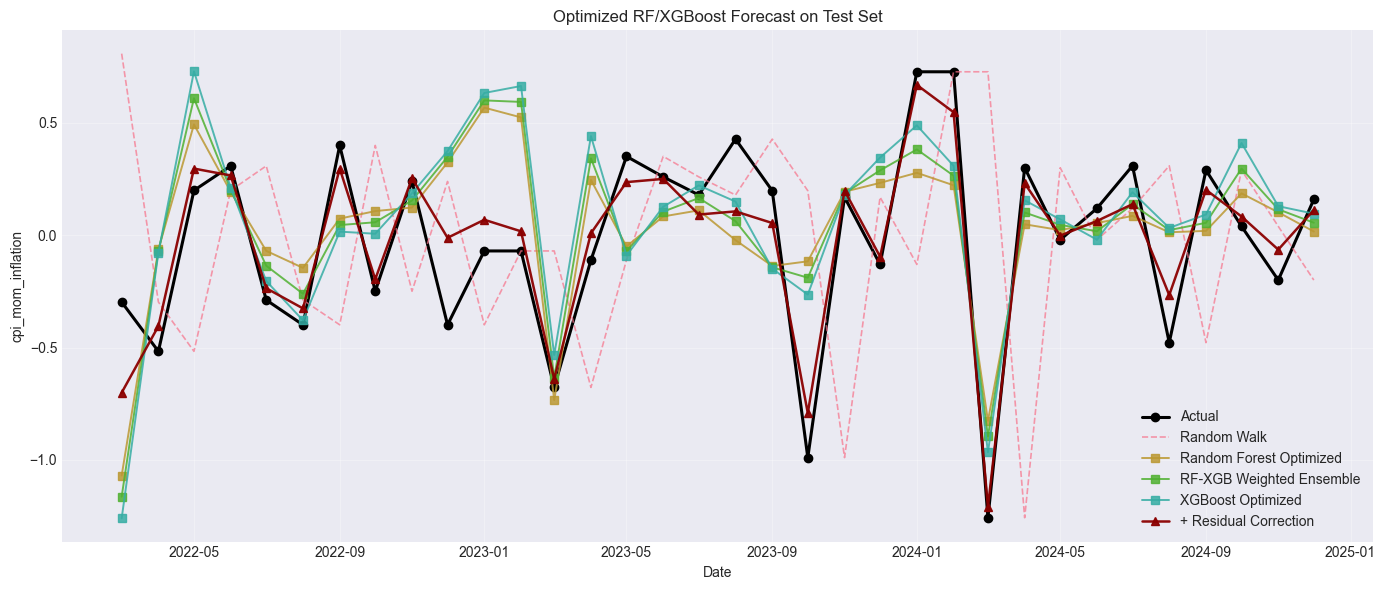

In [53]:
# Forecast plot with residual correction
pred_map = {
    "Random Forest Optimized": rf_test_pred,
    "RF-XGB Weighted Ensemble": ensemble_test_pred
}
if HAS_XGB:
    pred_map["XGBoost Optimized"] = xgb_test_pred

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(y_test.index, y_test.values, "o-", label="Actual", color="black", linewidth=2.2)
ax.plot(y_test.index[rw_mask], rw_pred[rw_mask], "--", label="Random Walk", linewidth=1.2, alpha=0.7)

for name, pred in pred_map.items():
    ax.plot(y_test.index, pred, marker="s", linestyle="-", linewidth=1.4, alpha=0.85, label=name)

# Add corrected forecast if available
if resid_model is not None:
    ax.plot(y_test.index, best_pred_corrected, "^-", label="+ Residual Correction", 
            linewidth=1.8, alpha=0.95, color="darkred")

ax.set_title("Optimized RF/XGBoost Forecast on Test Set")
ax.set_xlabel("Date")
ax.set_ylabel(target_var)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "optimized_test_forecast.png"), dpi=150)
plt.show()

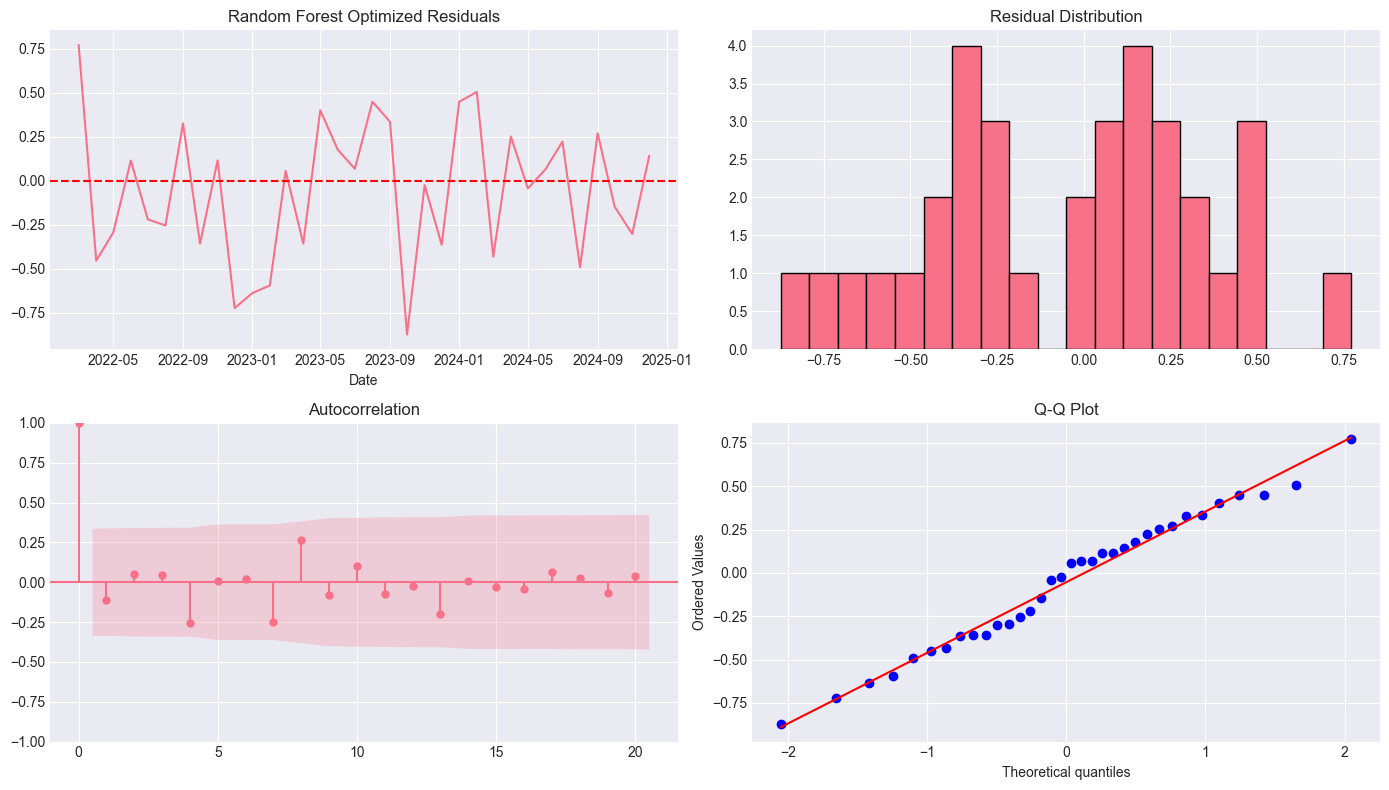

Residual mean: -0.054057
Residual std:  0.390699
Jarque-Bera p-value: 0.649707


In [54]:
# Residual diagnostics for the best available model.
if HAS_XGB and best_model_name == "XGBoost Optimized":
    best_pred = xgb_test_pred
elif best_model_name == "RF-XGB Weighted Ensemble":
    best_pred = ensemble_test_pred
else:
    best_pred = rf_test_pred

best_residuals = y_test.values - best_pred
max_lags = min(20, len(best_residuals) - 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes[0, 0].plot(y_test.index, best_residuals)
axes[0, 0].axhline(0, color="red", linestyle="--")
axes[0, 0].set_title(f"{best_model_name} Residuals")
axes[0, 0].set_xlabel("Date")

axes[0, 1].hist(best_residuals, bins=20, edgecolor="black")
axes[0, 1].set_title("Residual Distribution")

plot_acf(best_residuals, lags=max_lags, ax=axes[1, 0])
stats.probplot(best_residuals, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("Q-Q Plot")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "optimized_residual_diagnostics.png"), dpi=150)
plt.show()

jb_stat, jb_p = jarque_bera(best_residuals)
print(f"Residual mean: {np.mean(best_residuals):.6f}")
print(f"Residual std:  {np.std(best_residuals):.6f}")
print(f"Jarque-Bera p-value: {jb_p:.6f}")

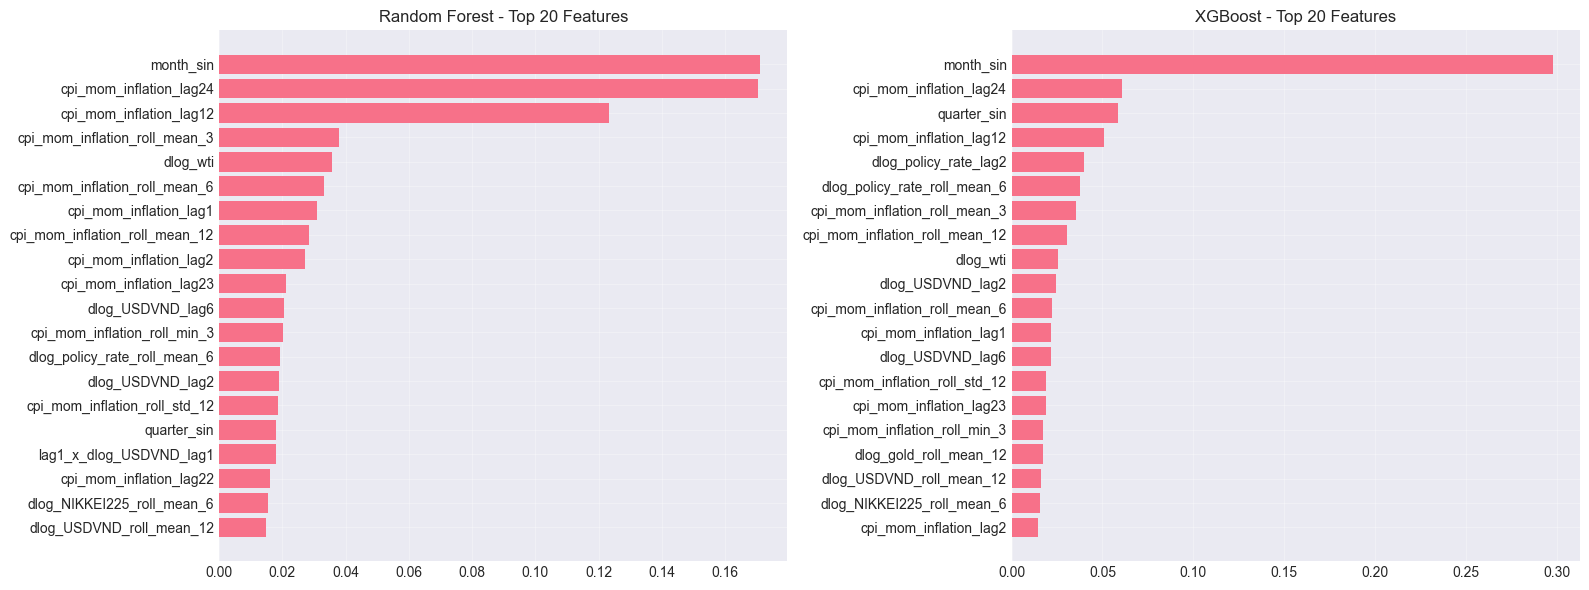

In [55]:
# Feature importance
fig, axes = plt.subplots(1, 2 if HAS_XGB else 1, figsize=(16 if HAS_XGB else 9, 6))
if not HAS_XGB:
    axes = [axes]

rf_imp = pd.DataFrame({"feature": X_train_sel.columns, "importance": rf_best.feature_importances_}).sort_values("importance", ascending=False).head(20)
axes[0].barh(rf_imp["feature"][::-1], rf_imp["importance"][::-1])
axes[0].set_title("Random Forest - Top 20 Features")
axes[0].grid(True, alpha=0.3)

if HAS_XGB:
    xgb_imp = pd.DataFrame({"feature": X_train_sel.columns, "importance": xgb_best.feature_importances_}).sort_values("importance", ascending=False).head(20)
    axes[1].barh(xgb_imp["feature"][::-1], xgb_imp["importance"][::-1])
    axes[1].set_title("XGBoost - Top 20 Features")
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "optimized_feature_importance.png"), dpi=150)
plt.show()

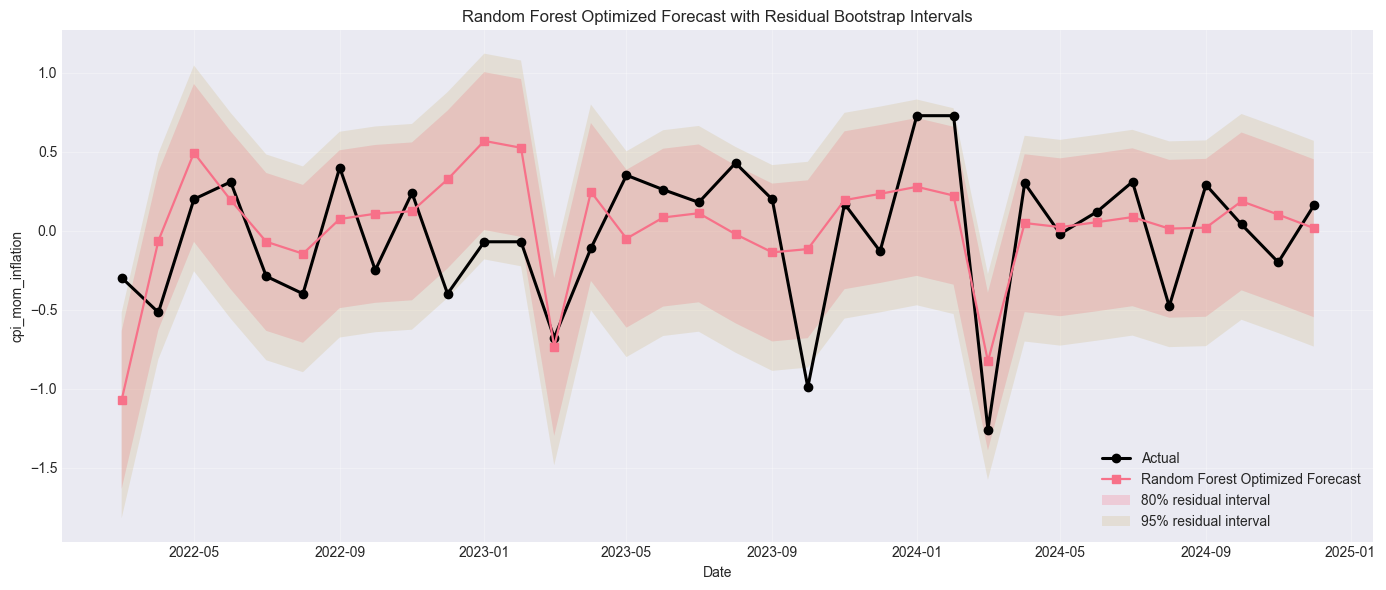

In [56]:
# Residual bootstrap prediction intervals for the selected best model.
# These intervals reflect empirical forecast error uncertainty on the test residual distribution.

def make_prediction_intervals(point_forecast, residuals, alpha_levels=(0.10, 0.05)):
    intervals = {}
    for alpha in alpha_levels:
        lower_q = np.quantile(residuals, alpha / 2)
        upper_q = np.quantile(residuals, 1 - alpha / 2)
        intervals[f"lower_{int((1-alpha)*100)}"] = point_forecast + lower_q
        intervals[f"upper_{int((1-alpha)*100)}"] = point_forecast + upper_q
    return intervals

intervals = make_prediction_intervals(best_pred, best_residuals, alpha_levels=(0.20, 0.05))

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(y_test.index, y_test.values, "o-", label="Actual", color="black", linewidth=2.2)
ax.plot(y_test.index, best_pred, "s-", label=f"{best_model_name} Forecast", linewidth=1.6)
ax.fill_between(y_test.index, intervals["lower_80"], intervals["upper_80"], alpha=0.25, label="80% residual interval")
ax.fill_between(y_test.index, intervals["lower_95"], intervals["upper_95"], alpha=0.15, label="95% residual interval")
ax.set_title(f"{best_model_name} Forecast with Residual Bootstrap Intervals")
ax.set_xlabel("Date")
ax.set_ylabel(target_var)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "optimized_prediction_intervals.png"), dpi=150)
plt.show()

✓ 12-month forecast with RON95 shock correction
            Random Forest Optimized + RON95 Correction
2025-01-01                                   -0.117660
2025-02-01                                    0.132243
2025-03-01                                    0.017632
2025-04-01                                   -0.912524
2025-05-01                                   -0.058492
2025-06-01                                   -0.001161
2025-07-01                                    0.003465
2025-08-01                                   -0.002196
2025-09-01                                   -0.052972
2025-10-01                                   -0.033826
2025-11-01                                   -0.052672
2025-12-01                                   -0.023964


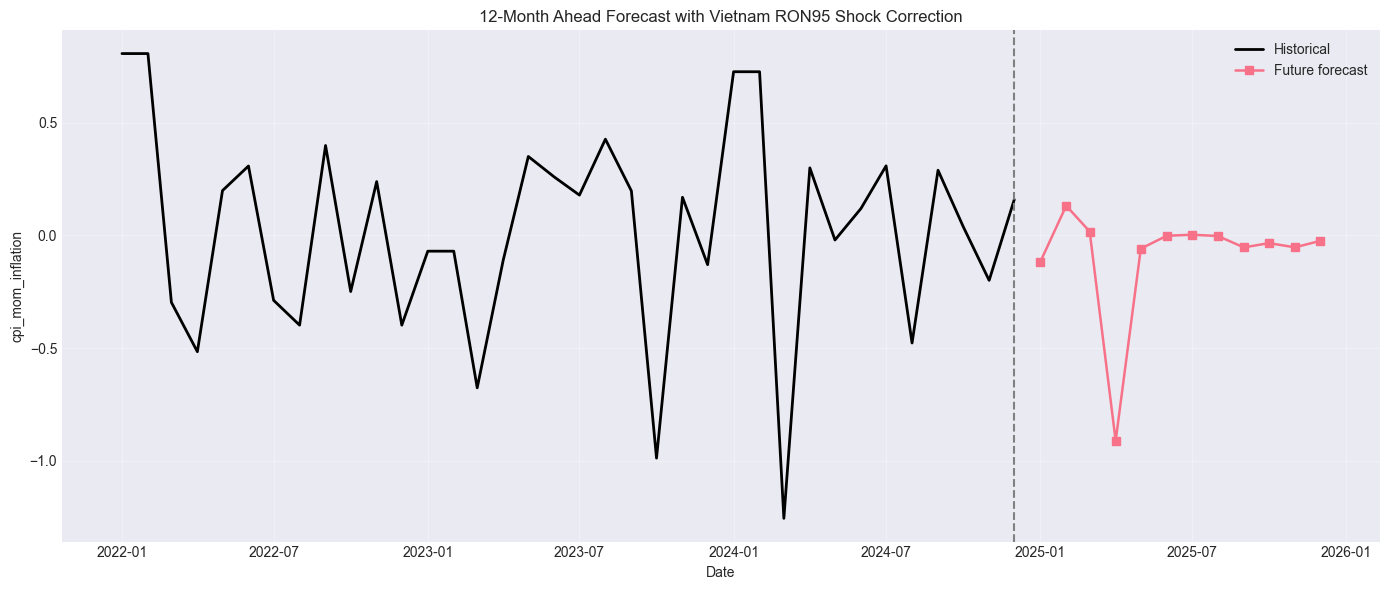

In [57]:
# Future forecasting with recursive updates and RON95 shock correction
future_steps = 12
future_index = pd.date_range(start=y.index[-1], periods=future_steps + 1, freq="MS")[1:]

history_df = df.copy()
future_preds = []
last_gas_price = gas_aligned.iloc[-1] if len(gas_aligned) > 0 else 0

# Choose production model
best_model = rf_best if best_model_name == "Random Forest Optimized" else xgb_best
if best_model_name == "RF-XGB Weighted Ensemble" and HAS_XGB:
    best_model = None

last_exog_values = df[exog_transformed].iloc[-1]

for future_date in future_index:
    # Add row with persistence for exog variables
    new_row = pd.Series(index=df.columns, dtype=float)
    new_row[target_var] = np.nan
    for col in exog_transformed:
        new_row[col] = last_exog_values[col]
    
    temp_df = pd.concat([history_df, pd.DataFrame([new_row], index=[future_date])])
    
    # Generate features
    X_temp, y_temp, _ = create_tree_features(temp_df, target_var, exog_transformed, max_target_lag=24)
    X_future = X_temp.iloc[[-1]][selected_features]
    
    # Base forecast
    if best_model_name == "RF-XGB Weighted Ensemble" and HAS_XGB:
        pred = w_rf * rf_best.predict(X_future)[0] + w_xgb * xgb_best.predict(X_future)[0]
    else:
        pred = best_model.predict(X_future)[0]
    
    # Apply RON95 shock correction
    if resid_model is not None:
        X_future_resid = pd.DataFrame({
            "resid_lag1": [future_preds[-1] - pred if len(future_preds) > 0 else 0],
            "resid_lag2": [residuals_ts.iloc[-1]],
            "resid_lag3": [residuals_ts.iloc[-2]],
            "ron95_lag1": [last_gas_price],
            "ron95_lag2": [gas_aligned.iloc[-1]],
            "ron95_lag3": [gas_aligned.iloc[-2]]
        })
        X_future_resid = X_future_resid[X_resid_simple.columns]
        pred += resid_model.predict(X_future_resid)[0]
    
    future_preds.append(pred)
    history_df.loc[future_date, target_var] = pred
    for col in exog_transformed:
        history_df.loc[future_date, col] = last_exog_values[col]

future_df = pd.DataFrame({best_model_name + (" + RON95 Correction" if resid_model else ""): future_preds}, index=future_index)
future_df.to_csv(os.path.join(OUTPUT_DIR, "optimized_future_forecast.csv"))

print("✓ 12-month forecast with RON95 shock correction")
print(future_df)

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(y.index[-36:], y.iloc[-36:], label="Historical", color="black", linewidth=2)
ax.plot(future_df.index, future_df.iloc[:, 0], "s-", label="Future forecast", linewidth=1.8)
ax.axvline(y.index[-1], color="gray", linestyle="--")
ax.set_title("12-Month Ahead Forecast with Vietnam RON95 Shock Correction")
ax.set_xlabel("Date")
ax.set_ylabel(target_var)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "optimized_future_forecast.png"), dpi=150)
plt.show()

In [58]:
print("\n" + "="*80)
print("OPTIMIZED RF/XGBOOST + RESIDUAL SHOCK CORRECTION SUMMARY")
print("="*80)
print(f"Target: {target_var}")
print(f"Original observations: {len(df_raw)}")
print(f"Supervised observations: {len(X)}")
print(f"Selected features: {len(selected_features)}")
print(f"Train period: {X_train.index.min().date()} to {X_train.index.max().date()}")
print(f"Validation period: {X_val.index.min().date()} to {X_val.index.max().date()}")
print(f"Test period: {X_test.index.min().date()} to {X_test.index.max().date()}")
print(f"Best model: {best_model_name}")

print(f"\n--- Base Model Performance ---")
print(results_df.sort_values("RMSE")[["Model", "RMSE", "MAE", "R2"]].to_string(index=False))

if resid_model is not None:
    print(f"\n--- Residual Correction (2018+) ---")
    print(f"Gasoline variable: {gas_var}")
    print(f"Residual model training samples: {X_resid_simple.shape[0]}")
    print(results_corrected_df[["Model", "RMSE", "MAE", "R2"]].to_string(index=False))
else:
    print(f"\n--- Residual Correction ---")
    print("✗ Residual model not trained (insufficient data or no gasoline variable)")

print("\n" + "="*80)


OPTIMIZED RF/XGBOOST + RESIDUAL SHOCK CORRECTION SUMMARY
Target: cpi_mom_inflation
Original observations: 360
Supervised observations: 335
Selected features: 35
Train period: 1997-02-01 to 2019-05-01
Validation period: 2019-06-01 to 2022-02-01
Test period: 2022-03-01 to 2024-12-01
Best model: Random Forest Optimized

--- Base Model Performance ---
                   Model     RMSE      MAE       R2
 Random Forest Optimized 0.394421 0.331945 0.163547
RF-XGB Weighted Ensemble 0.396678 0.326271 0.153948
       XGBoost Optimized 0.408808 0.326372 0.101410
           Mean Baseline 0.431260 0.341284 0.000000
             Random Walk 0.698073 0.533684      NaN

--- Residual Correction (2018+) ---
Gasoline variable: dlog_wti
Residual model training samples: 74
                                           Model     RMSE      MAE       R2
Random Forest Optimized + RON95 Shock Correction 0.147288 0.111347 0.883358
                         Random Forest Optimized 0.394421 0.331945 0.163547

